<a href="https://colab.research.google.com/github/alexadandridge/AdvancedMachineLearning/blob/master/Copy_of_Inclass_05_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# notebook for building CNN with cats & dogs dataset

In [2]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import random

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from pathlib import Path

data_dir = Path('/content/drive/MyDrive/cats_dogs')

print(data_dir.exists())

True


In [5]:
print(list(data_dir.iterdir()))

[PosixPath('/content/drive/MyDrive/cats_dogs/.DS_Store'), PosixPath('/content/drive/MyDrive/cats_dogs/cats_set'), PosixPath('/content/drive/MyDrive/cats_dogs/dogs_set')]


### Importing the raw cat and dog images

In [6]:
# importing the data (cat and dog images)


train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # resize ALL images to 128x128 (so all same shape)
    batch_size=32                               # number of images per batch
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio as training set
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same resizing as training set
    batch_size=32                               # same batch size as training set
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


#### To check if tf can access any GPU you have on your machine

In [7]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected and available for TensorFlow.")
else:
    print("No GPU detected. Training will use CPU.")

No GPU detected. Training will use CPU.


In [8]:
# View labels from the first training batch

for images, labels in train_ds_raw.take(1):

    print(labels.numpy())
    print(train_ds_raw.class_names)

[0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1]
['cats_set', 'dogs_set']


In [9]:
# class names
class_names = train_ds_raw.class_names
print(class_names)

['cats_set', 'dogs_set']


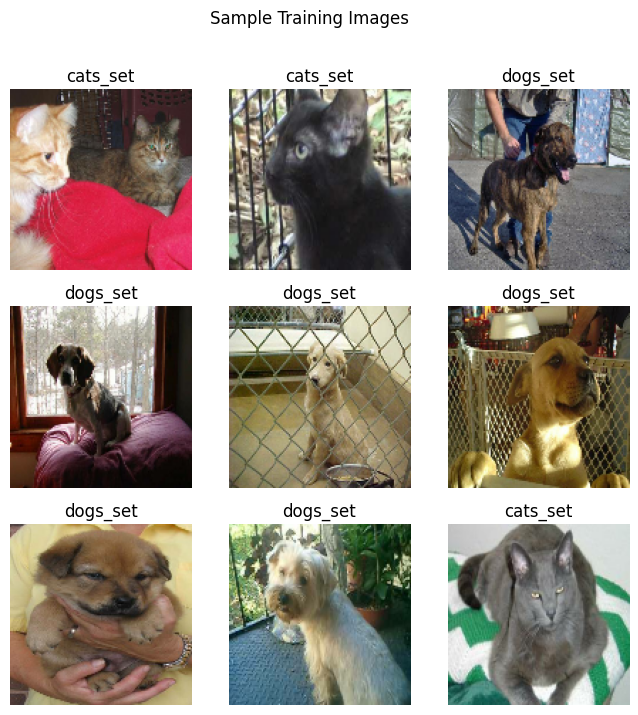

In [10]:
# View one batch of images
plt.figure(figsize=(8, 8))

for images, labels in train_ds_raw.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # display 0–255 RGB correctly
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Sample Training Images")
plt.show()

### Importing padded cat and dog images

In [11]:
# Re-import images with aspect-ratio preservation (padded instead of raw)

train_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # target size for all images
    batch_size=32,                              # number of images per batch
    pad_to_aspect_ratio=True                    # preserve image proportions and pad instead of stretching
)

val_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same target size
    batch_size=32,                              # same batch size
    pad_to_aspect_ratio=True                    # apply same preprocessing to validation data
)

# Split validation into validation + test (50/50 split)
val_batches = tf.data.experimental.cardinality(val_ds_padded).numpy()

test_ds_padded = val_ds_padded.take(val_batches // 2)
val_ds_padded = val_ds_padded.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds_padded).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds_padded).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds_padded).numpy())

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Train batches: 25
Validation batches: 4
Test batches: 3


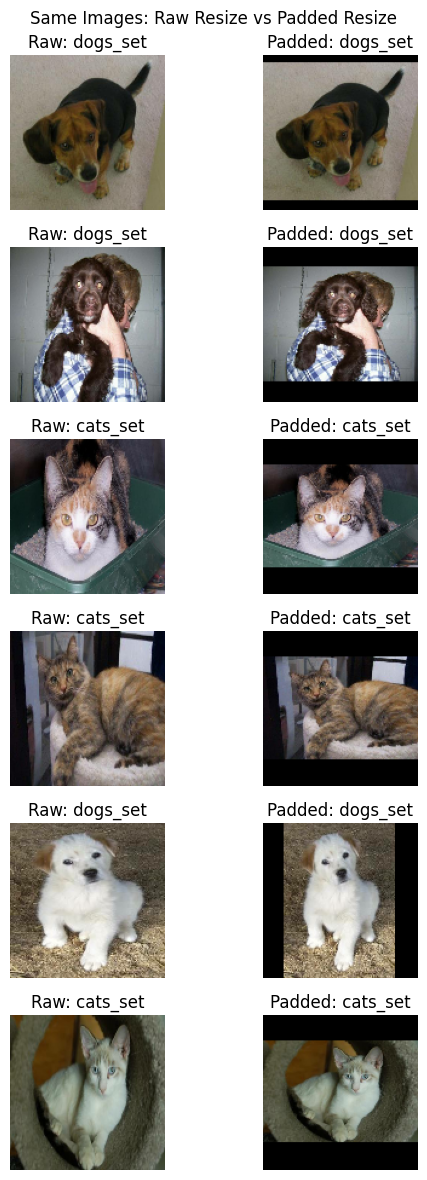

In [12]:
random.seed(42)

cat_paths = list(Path(data_dir).glob("cats_set/*"))
dog_paths = list(Path(data_dir).glob("dogs_set/*"))

image_paths = random.sample(cat_paths, 3) + random.sample(dog_paths, 3)
random.shuffle(image_paths)

plt.figure(figsize=(6, 12))

for i, path in enumerate(image_paths):
    img = tf.io.read_file(str(path))
    img = tf.image.decode_jpeg(img, channels=3)

    raw_img = tf.image.resize(img, (128, 128))
    padded_img = tf.image.resize_with_pad(img, 128, 128)

    label = path.parent.name

    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(raw_img.numpy().astype("uint8"))
    plt.title(f"Raw: {label}")
    plt.axis("off")

    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(padded_img.numpy().astype("uint8"))
    plt.title(f"Padded: {label}")
    plt.axis("off")

plt.suptitle("Same Images: Raw Resize vs Padded Resize")
plt.tight_layout()
plt.show()

### Normalize all data and shuffle train data

In [13]:
# Normalize pixel values from 0–255 to 0–1 for all datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_padded = train_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # normalize images; keep labels unchanged
)

val_ds_padded = val_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to validation data
)

test_ds_padded = test_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to test data
)

# Shuffle only the training data to improve learning
# Did above but best practice to do after all preprocessing steps
train_ds_padded = train_ds_padded.shuffle(
    1000,                                        # buffer size (>= dataset size for good mixing)
    seed=42                                      # ensures reproducible shuffling
)

In [14]:
# check normalization worked correctly (should be 0–1 range)
for images, labels in train_ds_padded.take(1):
    print(images.numpy().min(), images.numpy().max())

0.0 1.0


### Building the MLP model

In [15]:
# set random seed for reproducibility
tf.random.set_seed(42)

# Define the MLP model
mlp_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),       # input is a 128x128 color image
    layers.Flatten(),                        # convert image to a 1D vector (loses spatial structure)
    layers.Dense(128, activation="relu"),    # hidden layer learns patterns from pixel values
    layers.Dense(64, activation="relu"),     # deeper representation of patterns
    layers.Dense(1, activation="sigmoid")    # output: probability of one class (binary classification)
])

# Compile the model
mlp_catdog.compile(
    optimizer="adam",                        # optimization algorithm
    loss="binary_crossentropy",              # loss for binary classification
    metrics=["accuracy"]                     # track accuracy during training
)

# summary of the MLP model architecture
mlp_catdog.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# train the MLP model
mlp_history = mlp_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=10
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_catdog.evaluate(test_ds_padded, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.5138 - loss: 3.1094 - val_accuracy: 0.6154 - val_loss: 0.9323
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.5713 - loss: 0.8776 - val_accuracy: 0.5288 - val_loss: 1.0047
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.5962 - loss: 0.7246 - val_accuracy: 0.5288 - val_loss: 0.8751
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.6062 - loss: 0.7937 - val_accuracy: 0.4712 - val_loss: 1.7772
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.5838 - loss: 0.9267 - val_accuracy: 0.5096 - val_loss: 1.2314
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.6675 - loss: 0.7302 - val_accuracy: 0.5288 - val_loss: 0.7663
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.7525 - loss: 0.5154 - val_accuracy: 0.5577 - val_loss: 0.9903
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.7250 - loss: 0.5370 - val_accuracy: 0.

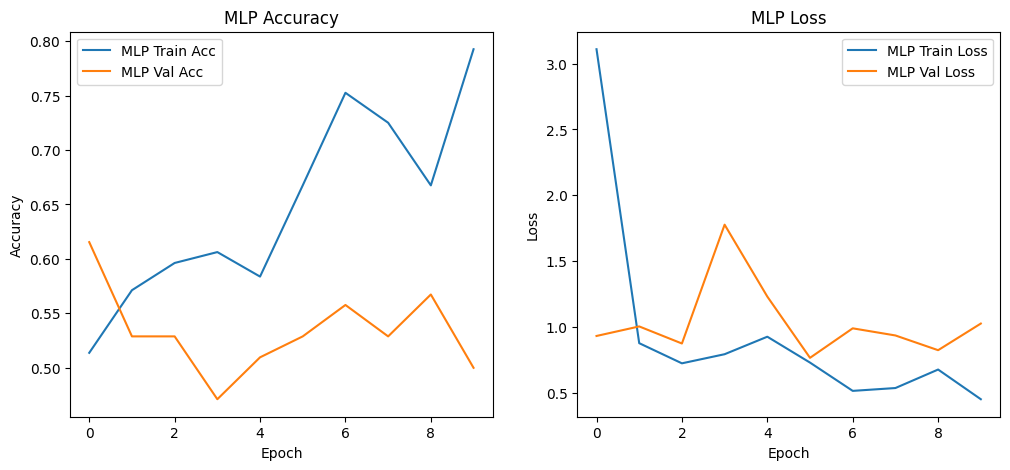

In [17]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_history.history['accuracy'], label='MLP Train Acc')
plt.plot(mlp_history.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mlp_history.history['loss'], label='MLP Train Loss')
plt.plot(mlp_history.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Building CNN model

In [18]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu",
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu",
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20                                      # increase if needed
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 941ms/step - accuracy: 0.5562 - loss: 0.8530 - val_accuracy: 0.5385 - val_loss: 0.6996
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 814ms/step - accuracy: 0.6350 - loss: 0.6370 - val_accuracy: 0.5481 - val_loss: 0.7232
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 820ms/step - accuracy: 0.7287 - loss: 0.5414 - val_accuracy: 0.5673 - val_loss: 0.7627
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 818ms/step - accuracy: 0.8100 - loss: 0.4216 - val_accuracy: 0.5385 - val_loss: 0.7599
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 861ms/step - accuracy: 0.8737 - loss: 0.3218 - val_accuracy: 0.5769 - val_loss: 0.9236
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 902ms/step - accuracy: 0.9137 - loss: 0.2275 - val_accuracy: 0.5673 - val_loss: 0.9658
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 820ms/step - accuracy: 0.9588 - loss: 0.1411 - val_accuracy: 0.5865 - val_loss: 0.9080
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 818ms/step - accuracy: 0.9850 - loss: 0.0861 - val_accu

### Visualizing CNN performance

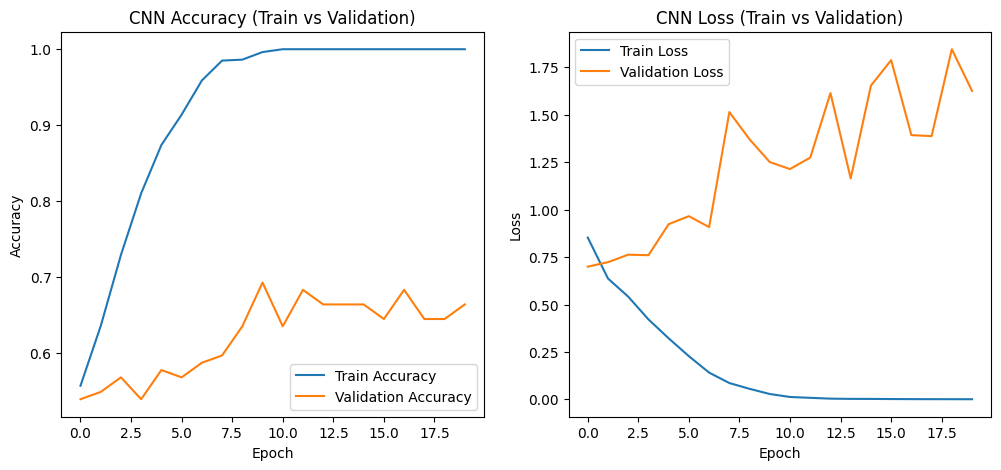

In [19]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### CNN with early stopping

In [20]:
# add early stopping to CNN model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",                         # watch validation loss
    patience=5,                                 # stop if no improvement for 5 epochs
    restore_best_weights=True                   # revert to best model after stopping
)

# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu",
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu",
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20,                                     # increase if needed
    callbacks=[early_stopping]                     # add early stopping callback
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 946ms/step - accuracy: 0.5562 - loss: 0.8056 - val_accuracy: 0.5865 - val_loss: 0.6807
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 846ms/step - accuracy: 0.6037 - loss: 0.6639 - val_accuracy: 0.5000 - val_loss: 0.7285
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 854ms/step - accuracy: 0.6562 - loss: 0.6266 - val_accuracy: 0.5865 - val_loss: 0.6606
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 830ms/step - accuracy: 0.6862 - loss: 0.5734 - val_accuracy: 0.5385 - val_loss: 0.7066
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 868ms/step - accuracy: 0.7763 - loss: 0.4993 - val_accuracy: 0.5962 - val_loss: 0.7093
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 885ms/step - accuracy: 0.8250 - loss: 0.3809 - val_accuracy: 0.6154 - val_loss: 0.7105
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 839ms/step - accuracy: 0.8950 - loss: 0.2831 - val_accuracy: 0.5673 - val_loss: 0.8186
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 927ms/step - accuracy: 0.9450 - loss: 0.1646 - val_accu

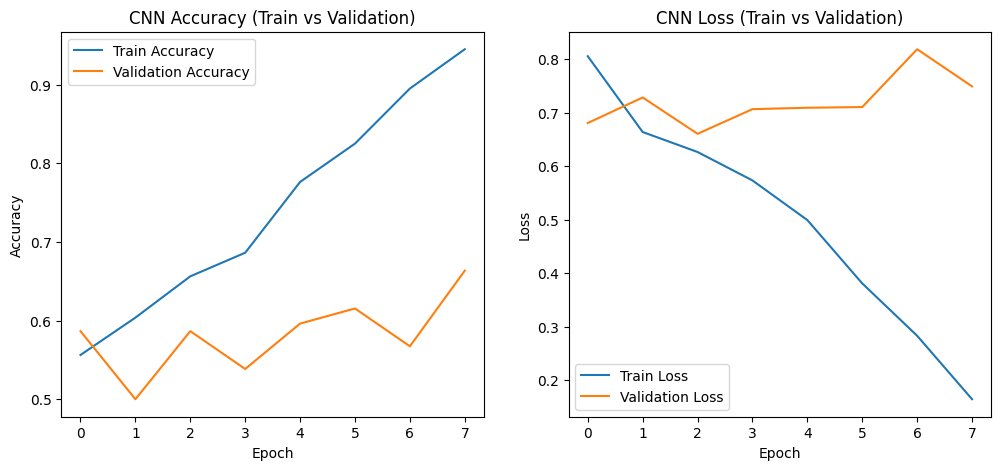

In [21]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### Does CNN performance improve with data augmentation?

In [22]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define data augmentation
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),                # randomly rotate training images
    layers.RandomFlip("horizontal")             # randomly flip images left/right
])

# define CNN model with data augmentation
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),          # input: 128x128 RGB image

    data_augmentation,                          # apply augmentation during training only

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# compile augmented CNN model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# train augmented CNN model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
)

# evaluate augmented CNN on test set
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 981ms/step - accuracy: 0.5213 - loss: 1.0522 - val_accuracy: 0.5096 - val_loss: 0.6936
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 935ms/step - accuracy: 0.5788 - loss: 0.6750 - val_accuracy: 0.5673 - val_loss: 0.6930
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 892ms/step - accuracy: 0.6325 - loss: 0.6430 - val_accuracy: 0.4712 - val_loss: 0.8047
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 940ms/step - accuracy: 0.6612 - loss: 0.6102 - val_accuracy: 0.5577 - val_loss: 0.7720
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 970ms/step - accuracy: 0.7038 - loss: 0.5871 - val_accuracy: 0.6250 - val_loss: 0.6598
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 884ms/step - accuracy: 0.6762 - loss: 0.5964 - val_accuracy: 0.5385 - val_loss: 0.6989
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 894ms/step - accuracy: 0.7138 - loss: 0.5715 - val_accuracy: 0.5577 - val_loss: 0.7288
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 889ms/step - accuracy: 0.6938 - loss: 0.5666 - val_accu

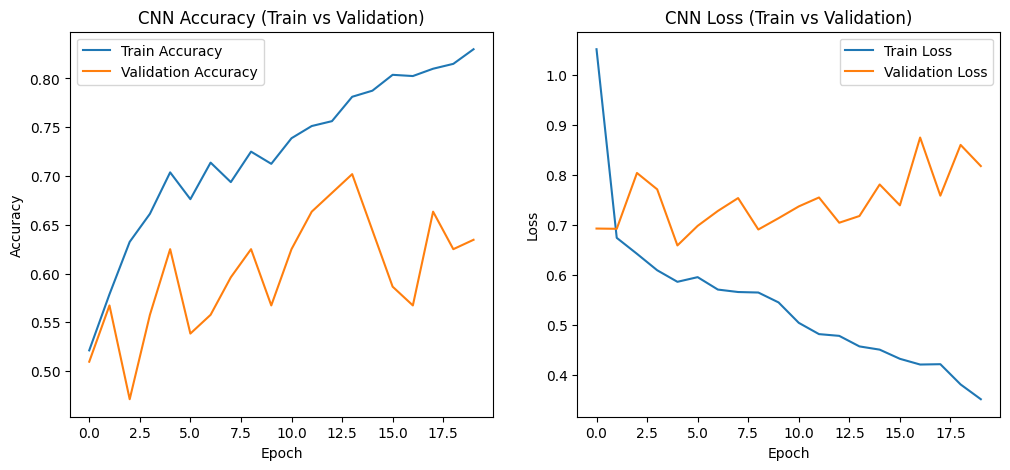

In [23]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code for you to experiment with

Use the code cell below as a starting point. Train at least 3 different CNN models by changing augmentation, regularization, and/or model capacity. Examples include adding rotation, zoom, L2 regularization, dropout, or another convolutional layer. Compare training, validation, and test performance, and explain which model generalizes best.

In [24]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.05),
    # layers.RandomZoom(0.05),
    # layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 853ms/step - accuracy: 0.5337 - loss: 0.7813 - val_accuracy: 0.4904 - val_loss: 0.6923
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 922ms/step - accuracy: 0.5950 - loss: 0.6670 - val_accuracy: 0.5288 - val_loss: 0.7330
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 844ms/step - accuracy: 0.6250 - loss: 0.6445 - val_accuracy: 0.5192 - val_loss: 0.7231
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 843ms/step - accuracy: 0.6963 - loss: 0.5906 - val_accuracy: 0.5192 - val_loss: 0.6971
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 848ms/step - accuracy: 0.7038 - loss: 0.5597 - val_accuracy: 0.5385 - val_loss: 0.7305
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 955ms/step - accuracy: 0.7638 - loss: 0.4963 - val_accuracy: 0.6731 - val_loss: 0.6389
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 933ms/step - accuracy: 0.7875 - loss: 0.4209 - val_accuracy: 0.6346 - val_loss: 0.7144
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 869ms/step - accuracy: 0.8462 - loss: 0.3457 - val_accu

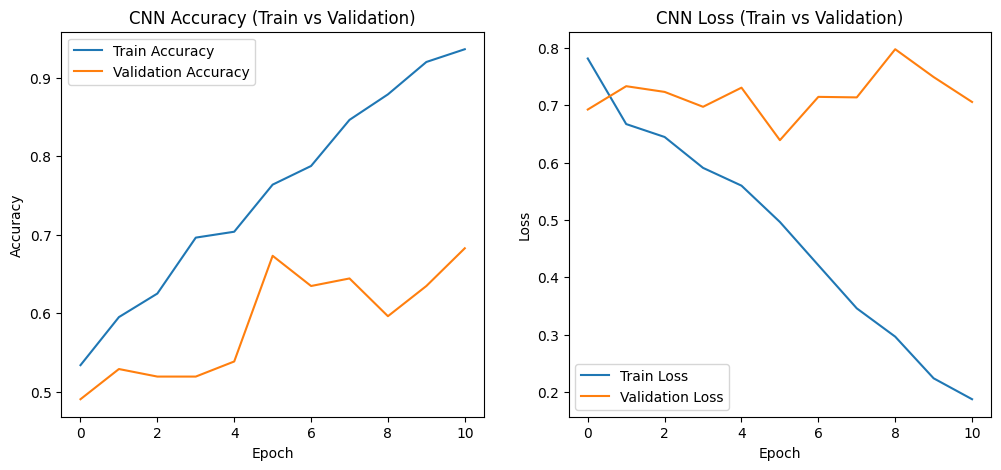

In [25]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code cells for your 3+ models. Make sure to annotate for each, explaining what you tried

First Model

In [29]:
# Model 1: Rotation Augmentation, Simple CNN
# This model tests whether adding a small rotation to the starter flip augmentation

# model tests whether adding small image augmentations imporves generalizations while keeping the CNN architecture relatively simple.
data_augmentation_1 = models.Sequential([
    layers.RandomFlip("horizontal"),  #randomly flips images left/right
    layers.RandomRotation(0.05)   # randomly rotates images slightly
])
# early stopping helps prevent overfitting: training stops if validation loss does not improve for 5 epochs
early_stopping_1 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

tf.random.set_seed(42)

cnn_model_1 = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation_1,
# this convolutional layer learns simple image features: 32 filters allows the network to learn multiple low-level visual features
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)), # max pooling reduces the spatial size of feature maps
# this second layer learns more complex patterns: increasing to 64 filters gives the model greater representational power
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),  # flatten converts the learned feature maps into one-dimensional vector
    layers.Dense(64, activation="relu"), # the dense layer combines extracted image features to make teh final classification decision
    layers.Dense(1, activation="sigmoid") # the output layer performs binary classification
])
# configuring the CNN before trainig
cnn_model_1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_history_1 = cnn_model_1.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_1]
)

cnn_test_loss_1, cnn_test_acc_1 = cnn_model_1.evaluate(test_ds_padded)

print(f"Model 1 test accuracy: {cnn_test_acc_1:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 985ms/step - accuracy: 0.5412 - loss: 0.7940 - val_accuracy: 0.5577 - val_loss: 0.6918
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 931ms/step - accuracy: 0.5950 - loss: 0.6749 - val_accuracy: 0.5673 - val_loss: 0.6880
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 914ms/step - accuracy: 0.6025 - loss: 0.6574 - val_accuracy: 0.5769 - val_loss: 0.7027
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 896ms/step - accuracy: 0.6275 - loss: 0.6374 - val_accuracy: 0.6058 - val_loss: 0.6945
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 996ms/step - accuracy: 0.6875 - loss: 0.6004 - val_accuracy: 0.5577 - val_loss: 0.7520
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 965ms/step - accuracy: 0.6913 - loss: 0.5894 - val_accuracy: 0.6442 - val_loss: 0.6380
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 917ms/step - accuracy: 0.6862 - loss: 0.5832 - val_accuracy: 0.5769 - val_loss: 0.6667
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 898ms/step - accuracy: 0.7200 - loss: 0.5589 - val_accu

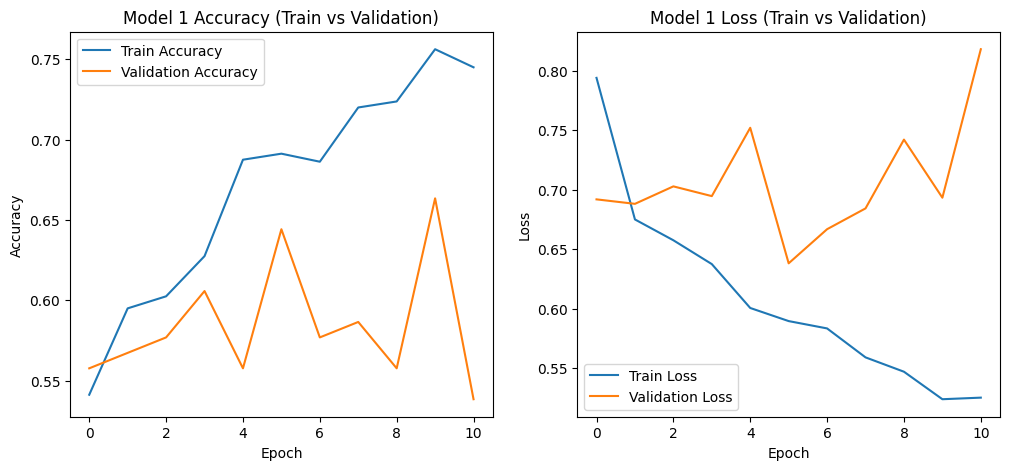

In [30]:
# visualizing train vs validation accuracy for Model 1
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history_1.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history_1.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 1 Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for Model 1
plt.subplot(1, 2, 2)
plt.plot(cnn_history_1.history["loss"], label="Train Loss")
plt.plot(cnn_history_1.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 1 Loss (Train vs Validation)")
plt.legend()

plt.show()

The model is still overfitting. Training accuracy increased to 0.75, btu validation accuracy was only 0.57. Training loss steadily decreased, while validation loss remained unstable and eventually increased. This validation accuracy (0.57) is lower than the example from above (0.65). Adding rotation augmentation did not help the model generalize better. The model may not have enough capacity or regularization to handle the variation made by rotations.

In [31]:
# Model 2: Zoom augmentation + larger CNN + dropout
# This model tests whether increasing model capacity while adding dropout
# helps improve generalization and reduce overfitting.
data_augmentation_2 = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.05) #randomly zooms into images slightly
])

early_stopping_2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

tf.random.set_seed(42)

cnn_model_2 = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation_2,
# first convolutional layer learns low-level visual features such as edges and textures. 64 filters give the model more capacity than model 1
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
# 128 filters increases model capacity further
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
# drop out randomly disables neurons during training
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

cnn_model_2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_history_2 = cnn_model_2.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_2]
)

cnn_test_loss_2, cnn_test_acc_2 = cnn_model_2.evaluate(test_ds_padded)

print(f"Model 2 test accuracy: {cnn_test_acc_2:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.5288 - loss: 0.9922 - val_accuracy: 0.5288 - val_loss: 0.6903
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.5288 - loss: 0.6845 - val_accuracy: 0.5096 - val_loss: 0.7073
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.5913 - loss: 0.6720 - val_accuracy: 0.5192 - val_loss: 0.7402
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.6225 - loss: 0.6640 - val_accuracy: 0.5192 - val_loss: 0.6951
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.6400 - loss: 0.6544 - val_accuracy: 0.5769 - val_loss: 0.7085
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6500 - loss: 0.6448 - val_accuracy: 0.5865 - val_loss: 0.6920
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 516ms/step - accuracy: 0.5417 - loss: 0.6898
Model 2 test accuracy: 0.5417


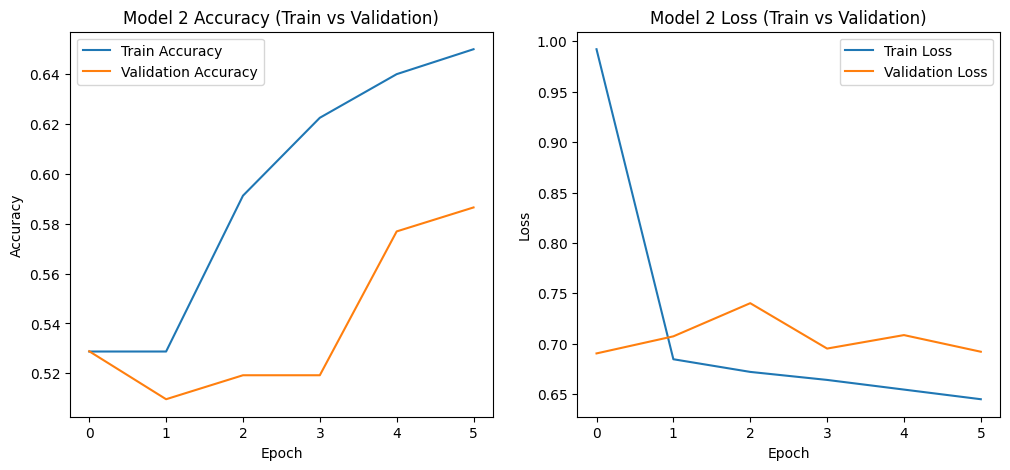

In [32]:
# visualizing train vs validation accuracy for Model 2
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(
    cnn_history_2.history["accuracy"],
    label="Train Accuracy"
)
plt.plot(
    cnn_history_2.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 2 Accuracy (Train vs Validation)")
plt.legend()

# plotting train vs validation loss for Model 2
plt.subplot(1, 2, 2)

plt.plot(
    cnn_history_2.history["loss"],
    label="Train Loss"
)

plt.plot(
    cnn_history_2.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 2 Loss (Train vs Validation)")
plt.legend()

plt.show()

Wow! This made things worse. Training accuracy only reached about 0.65, and validation accuracy remained around 0.54. After 1 epoch, validation loss stayed mostly flat and unstable. The model did not learn useful generalized features, and dropout may have reduced learning too much.

In [33]:
# Model 3: Stronger augmentation + deeper CNN + Batch Normalization + Dropout
# This model tests whether added capacity and regularization improve generalization.

data_augmentation_3 = models.Sequential([
    layers.RandomFlip("horizontal"), # randomly flips images during training
    layers.RandomZoom(0.05), # randomly zooms into images slightly
    layers.RandomTranslation(0.05, 0.05) # randomly shifts images
])

early_stopping_3 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

tf.random.set_seed(42)

cnn_model_3 = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation_3,

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.1),

    layers.Dense(1, activation="sigmoid")
])

cnn_model_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_history_3 = cnn_model_3.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=30,
    callbacks=[early_stopping_3]
)

cnn_test_loss_3, cnn_test_acc_3 = cnn_model_3.evaluate(test_ds_padded)

print(f"Model 3 test accuracy: {cnn_test_acc_3:.4f}")

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.5612 - loss: 2.2391 - val_accuracy: 0.5769 - val_loss: 0.6877
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.6275 - loss: 0.8350 - val_accuracy: 0.4904 - val_loss: 0.6926
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.6725 - loss: 0.6101 - val_accuracy: 0.5096 - val_loss: 0.6973
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.6538 - loss: 0.6115 - val_accuracy: 0.5288 - val_loss: 0.6892
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.7000 - loss: 0.5680 - val_accuracy: 0.4808 - val_loss: 0.7047
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.7325 - loss: 0.5468 - val_accuracy: 0.5577 - val_loss: 0.6750
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6913 - loss: 0.5763 - val_accuracy: 0.5577 - val_loss: 0.7174
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.7412 - loss: 0.5243 - val_accuracy: 0.5385 - val_loss:

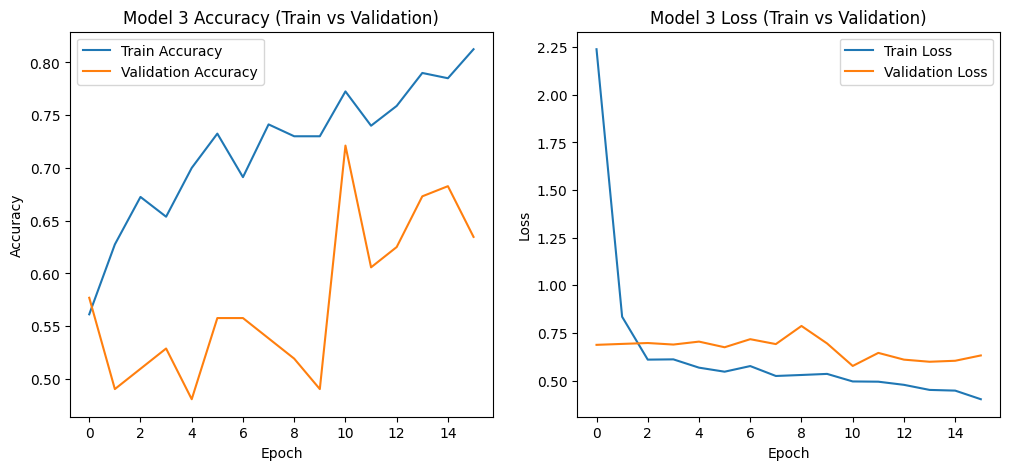

In [34]:
# visualizing train vs validation accuracy for Model 3
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history_3.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history_3.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 3 Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for Model 3
plt.subplot(1, 2, 2)
plt.plot(cnn_history_3.history["loss"], label="Train Loss")
plt.plot(cnn_history_3.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 3 Loss (Train vs Validation)")
plt.legend()

plt.show()

Okay, okay! This looks better. I reached my highest accuracy of 0.75 for the test data. All of my other models did worse than the starter one, so I am very happy with this improvement. The training accuracy was about 0.81 and the test accuracy was about 0.72. There is still some overfitting, but the gap is smaller and test accuracy is much stronger.

### What seemed to help model performance most in your experiments?

The combination of increased model capacity and regularization seemed to help performance the most. Model 3 performed the best and combined multiple things liek data augmentation, an additional convolution layer, batch normalization, dropout regularization, and a smaller learning rate.